# Random Forest Classifier — An Illustrated Tour

> A single decision tree is high-variance. A **Random Forest** averages hundreds of diverse trees, dramatically improving stability and accuracy.

---

**What we cover:**
- The single-tree problem — variance from different training sets
- Bootstrap sampling — each tree sees different data
- Random feature selection — decorrelating the trees
- Majority vote — the ensemble decision
- Stability as the forest grows
- Feature importance and OOB error
- ROC curve and metrics

## The picture — bagged trees + feature subsampling → smoother boundary

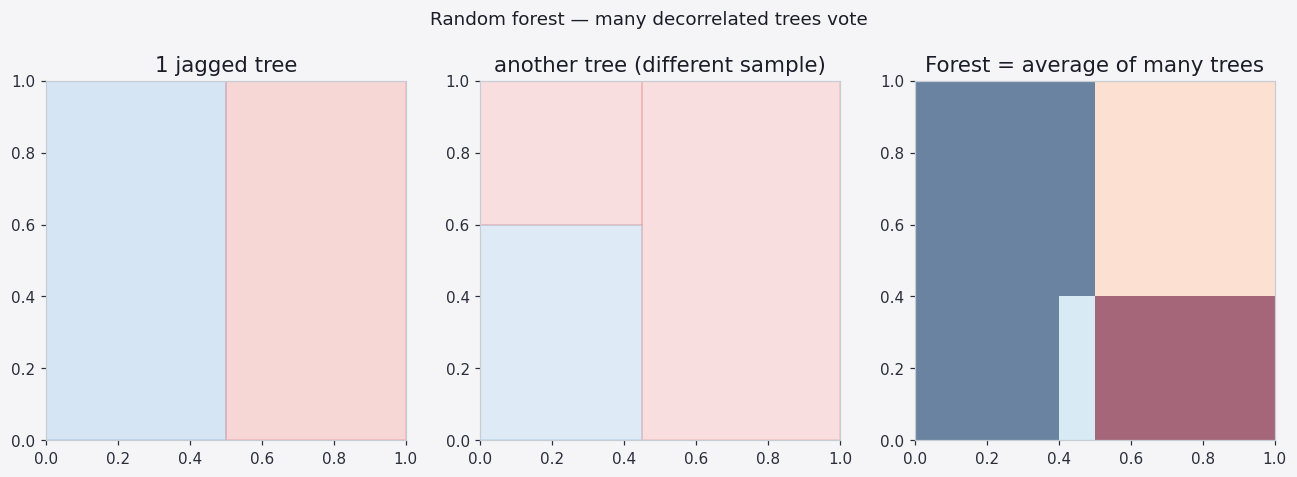

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
xx, yy = np.meshgrid(np.linspace(0,1,80), np.linspace(0,1,80))
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes[0]
ax.add_patch(Rectangle((0,0),0.5,1, color=P[0], alpha=0.25))
ax.add_patch(Rectangle((0.5,0),0.5,1, color=P[1], alpha=0.25))
ax.set_title('1 jagged tree')
ax = axes[1]
ax.add_patch(Rectangle((0,0),0.45,0.6, color=P[0], alpha=0.2))
ax.add_patch(Rectangle((0.45,0),0.55,1, color=P[1], alpha=0.2))
ax.add_patch(Rectangle((0,0.6),0.45,0.4, color=P[1], alpha=0.2))
ax.set_title('another tree (different sample)')
ax = axes[2]
Z = (xx>0.5).astype(float) + 0.6*(yy<0.4).astype(float)*(xx>0.4)
ax.imshow(Z, extent=[0,1,0,1], origin='lower', cmap='RdBu_r', alpha=0.6)
ax.set_title('Forest = average of many trees')
for a in axes: a.set_aspect('equal'); a.set_xlim(0,1); a.set_ylim(0,1)
fig.suptitle('Random forest — many decorrelated trees vote', y=1.03)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              accuracy_score, precision_score, recall_score, f1_score)

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

np.random.seed(1)
X2, y2   = make_moons(n_samples=180, noise=0.25, random_state=1)
xx, yy   = np.meshgrid(np.linspace(-2.5, 3.5, 300), np.linspace(-1.5, 2.5, 300))

X, y = make_classification(n_samples=200, n_features=20, n_informative=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print('Ready')

Ready


---
## The High-Variance Problem

Train the same tree on different bootstrap samples — the boundary changes dramatically.
High variance means the model is unstable and sensitive to which data it sees.

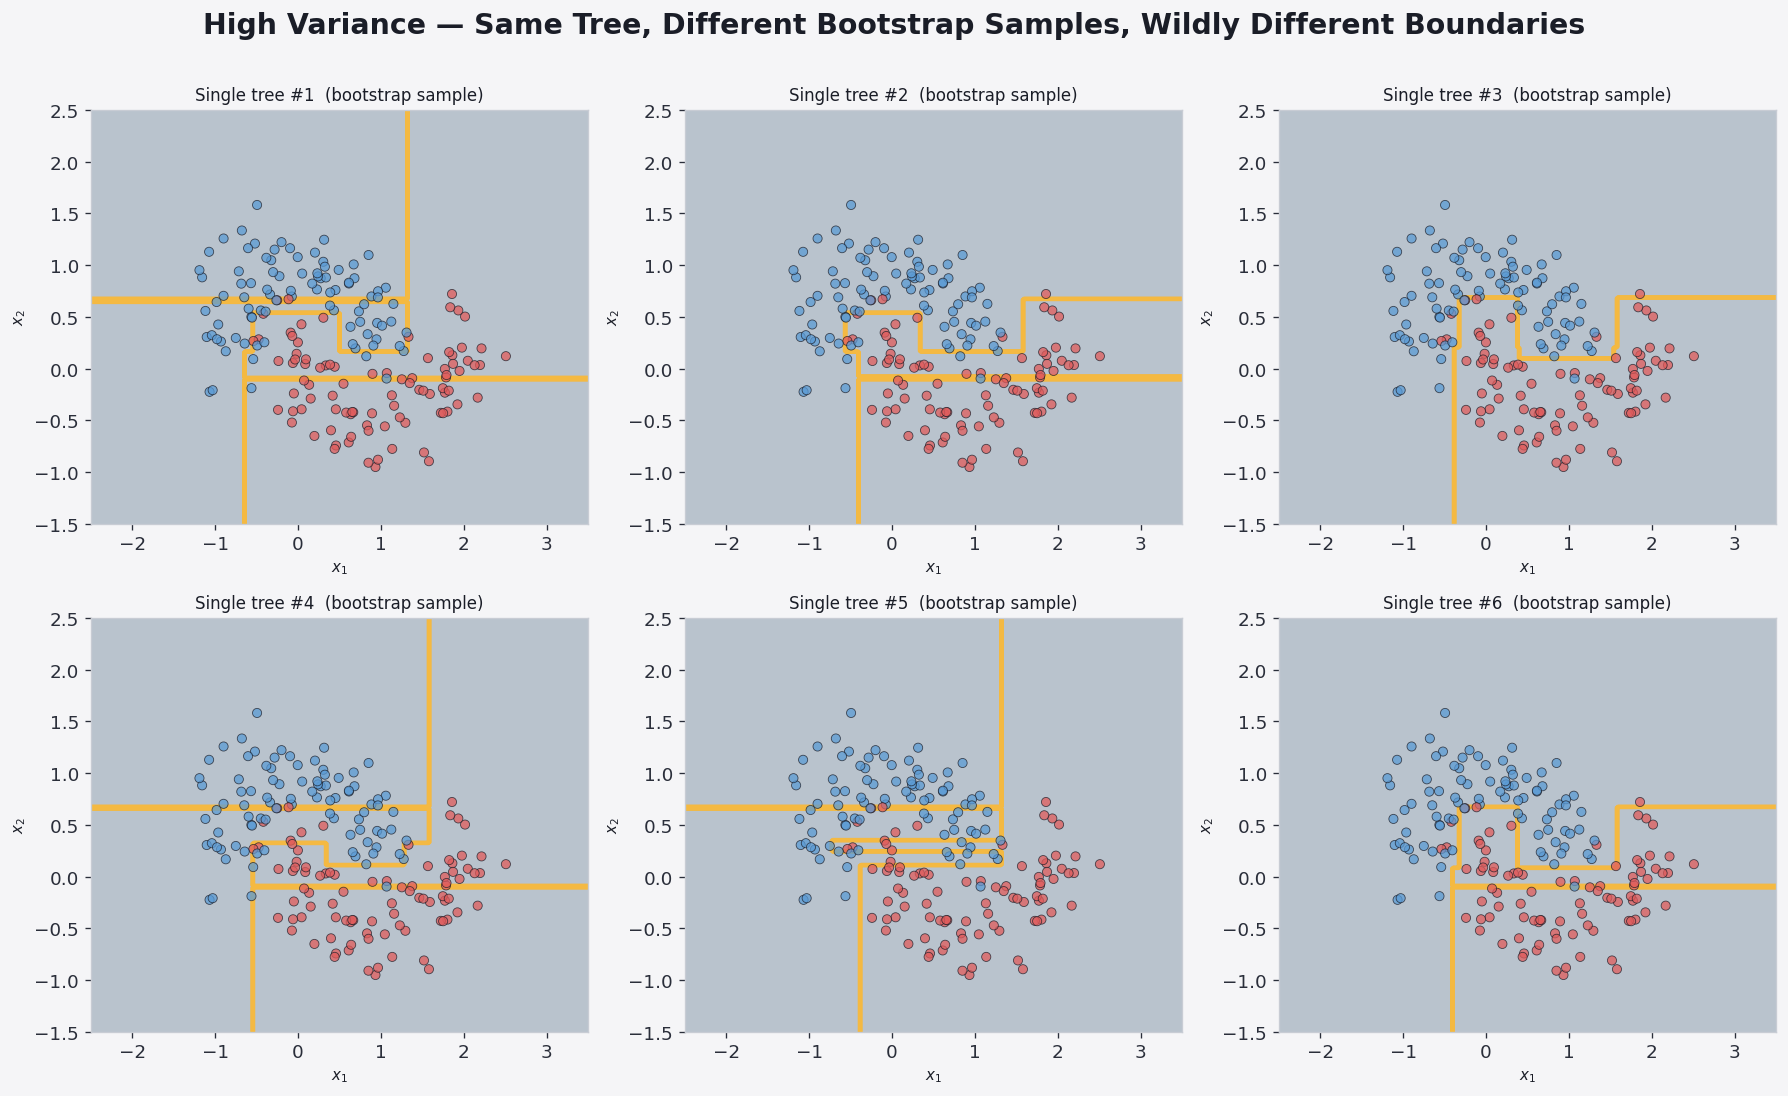

In [3]:
rng = np.random.default_rng(0)
n_boot = 6
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    idx = rng.integers(0, len(X2), len(X2))
    clf = DecisionTreeClassifier(max_depth=5, random_state=i)
    clf.fit(X2[idx], y2[idx])
    ZZ = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, ZZ, alpha=0.3, colors=['#1a3a5c','#5c1a1a'])
    ax.contour(xx, yy, ZZ, colors=CB, linewidths=2)
    ax.scatter(X2[:,0], X2[:,1], c=[C1 if yi else C0 for yi in y2],
               s=30, edgecolors='#1a1d27', lw=0.5, alpha=0.75, zorder=4)
    ax.set_title(f'Single tree #{i+1}  (bootstrap sample)', fontsize=10)
    ax.set_xlabel('$x_1$', fontsize=9); ax.set_ylabel('$x_2$', fontsize=9)

fig.suptitle('High Variance — Same Tree, Different Bootstrap Samples, Wildly Different Boundaries',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Majority Vote — The Ensemble Decision

Each tree votes for a class. The class with the **most votes** wins.
Averaging probability estimates gives a smoother, more confident prediction than any single tree.

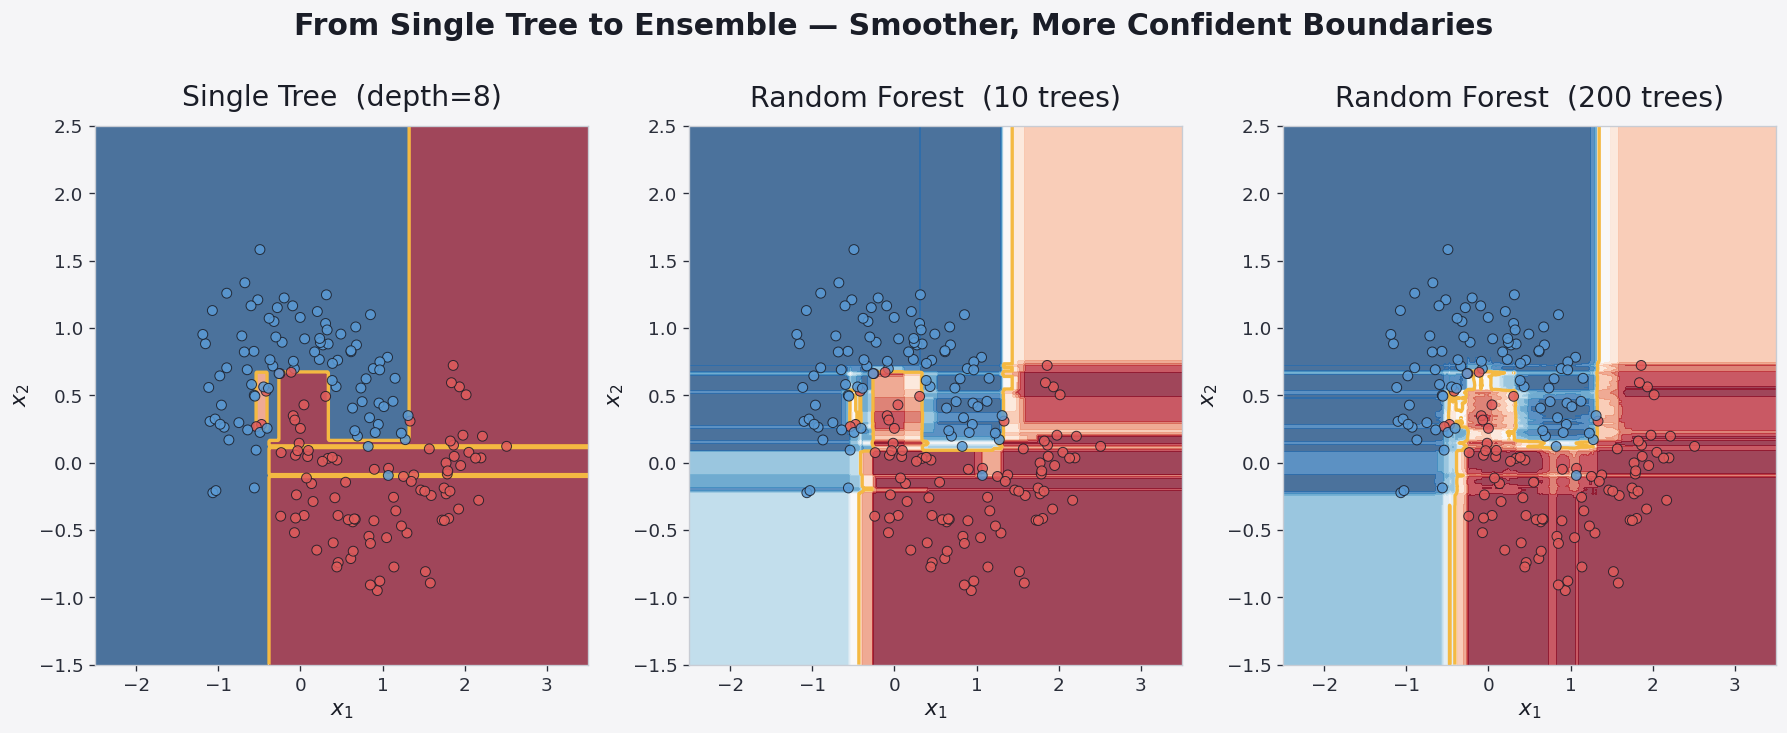

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Single deep tree
ax = axes[0]
clf_single = DecisionTreeClassifier(max_depth=8, random_state=0)
clf_single.fit(X2, y2)
ZZ_s = clf_single.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
im = ax.contourf(xx, yy, ZZ_s, levels=15, cmap='RdBu_r', alpha=0.75)
ax.contour(xx, yy, ZZ_s, levels=[0.5], colors=CB, linewidths=2)
ax.scatter(X2[:,0], X2[:,1], c=[C1 if yi else C0 for yi in y2],
           s=35, edgecolors='#1a1d27', lw=0.6, alpha=0.85, zorder=4)
ax.set_title('Single Tree  (depth=8)', pad=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(False)

# RF with 10 trees
ax = axes[1]
rf10 = RandomForestClassifier(n_estimators=10, max_depth=8, random_state=0)
rf10.fit(X2, y2)
ZZ_10 = rf10.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
ax.contourf(xx, yy, ZZ_10, levels=15, cmap='RdBu_r', alpha=0.75)
ax.contour(xx, yy, ZZ_10, levels=[0.5], colors=CB, linewidths=2)
ax.scatter(X2[:,0], X2[:,1], c=[C1 if yi else C0 for yi in y2],
           s=35, edgecolors='#1a1d27', lw=0.6, alpha=0.85, zorder=4)
ax.set_title('Random Forest  (10 trees)', pad=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(False)

# RF with 200 trees
ax = axes[2]
rf200 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=0)
rf200.fit(X2, y2)
ZZ_200 = rf200.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
im2 = ax.contourf(xx, yy, ZZ_200, levels=15, cmap='RdBu_r', alpha=0.75)
ax.contour(xx, yy, ZZ_200, levels=[0.5], colors=CB, linewidths=2)
ax.scatter(X2[:,0], X2[:,1], c=[C1 if yi else C0 for yi in y2],
           s=35, edgecolors='#1a1d27', lw=0.6, alpha=0.85, zorder=4)
ax.set_title('Random Forest  (200 trees)', pad=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(False)

fig.suptitle('From Single Tree to Ensemble — Smoother, More Confident Boundaries',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Stability — More Trees, Lower Variance

Test accuracy and prediction uncertainty both stabilise as we add more trees.
There is a point of diminishing returns — adding trees beyond ~100–200 rarely helps.

/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/sandeep/workspace/learn-ml/.ve

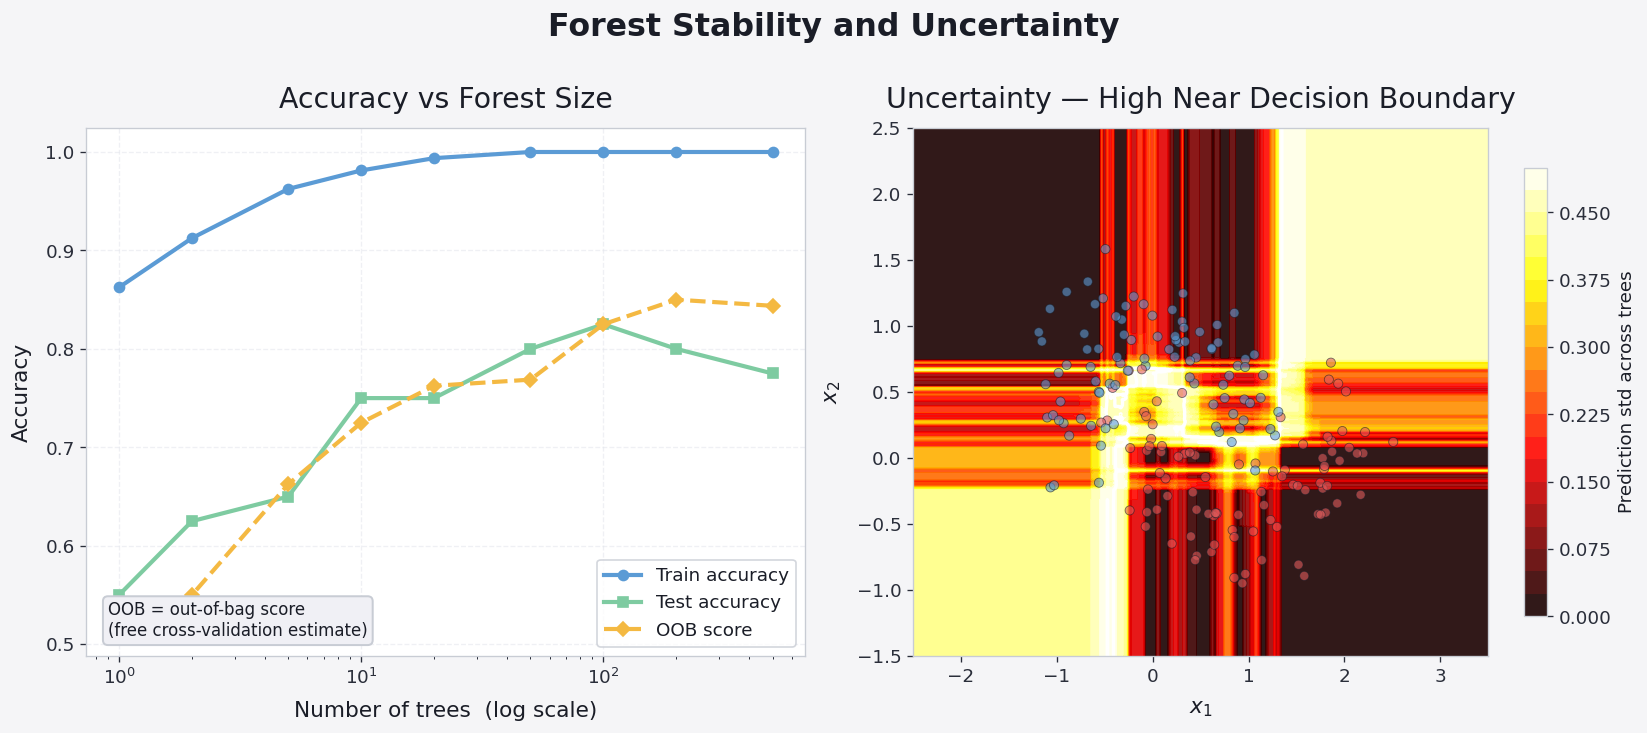

In [5]:
n_est_list = [1, 2, 5, 10, 20, 50, 100, 200, 500]
train_acc_list, test_acc_list, oob_list = [], [], []

for n_est in n_est_list:
    rf = RandomForestClassifier(n_estimators=n_est, max_depth=8,
                                 max_features='sqrt', oob_score=True, random_state=0)
    rf.fit(X_tr, y_tr)
    train_acc_list.append(accuracy_score(y_tr, rf.predict(X_tr)))
    test_acc_list.append(accuracy_score(y_te, rf.predict(X_te)))
    oob_list.append(rf.oob_score_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.semilogx(n_est_list, train_acc_list, color=C0, lw=2.5, marker='o', ms=6, label='Train accuracy')
ax.semilogx(n_est_list, test_acc_list,  color=CM, lw=2.5, marker='s', ms=6, label='Test accuracy')
ax.semilogx(n_est_list, oob_list,       color=CB, lw=2.5, marker='D', ms=6, ls='--', label='OOB score')
ax.set_xlabel('Number of trees  (log scale)', labelpad=8)
ax.set_ylabel('Accuracy', labelpad=8)
ax.set_title('Accuracy vs Forest Size', pad=12)
ax.legend(loc='lower right'); ax.grid(True)
ax.text(0.03, 0.03, 'OOB = out-of-bag score\n(free cross-validation estimate)',
        transform=ax.transAxes, fontsize=10, va='bottom',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec='#c8ccd4', lw=1.2))

# Right: prediction disagreement across trees (variance)
ax = axes[1]
all_preds = np.array([t.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
                      for t in rf200.estimators_])
std_map = all_preds.std(axis=0).reshape(xx.shape)
im = ax.contourf(xx, yy, std_map, levels=20, cmap='hot', alpha=0.9)
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Prediction std across trees', fontsize=11)
cbar.ax.tick_params(labelcolor='#2a2e3a')
ax.contour(xx, yy, ZZ_200, levels=[0.5], colors='#ffffff', linewidths=2)
ax.scatter(X2[:,0], X2[:,1], c=[C1 if yi else C0 for yi in y2],
           s=30, edgecolors='#1a1d27', lw=0.5, alpha=0.6, zorder=5)
ax.set_xlabel('$x_1$', labelpad=8); ax.set_ylabel('$x_2$', labelpad=8)
ax.set_title('Uncertainty — High Near Decision Boundary', pad=12)
ax.grid(False)

fig.suptitle('Forest Stability and Uncertainty', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Visual Sweep — Forest Size & Feature Subset

Two knobs control a Random Forest's bias-variance trade-off:

- **`n_estimators`** — more trees → lower variance, but with diminishing returns. The OOB error typically plateaus past ~100–200 trees.
- **`max_features`** — how many features each split considers. Smaller values **decorrelate** trees (a key trick of the Random Forest), trading per-tree accuracy for ensemble diversity.

The grid below shows the **2-D ensemble boundary** at six forest sizes. The follow-up plot tracks OOB error across `n_estimators` for three values of `max_features` — notice how the lowest curve uses a small feature subset (most decorrelated), and how all three flatten beyond a couple of hundred trees.


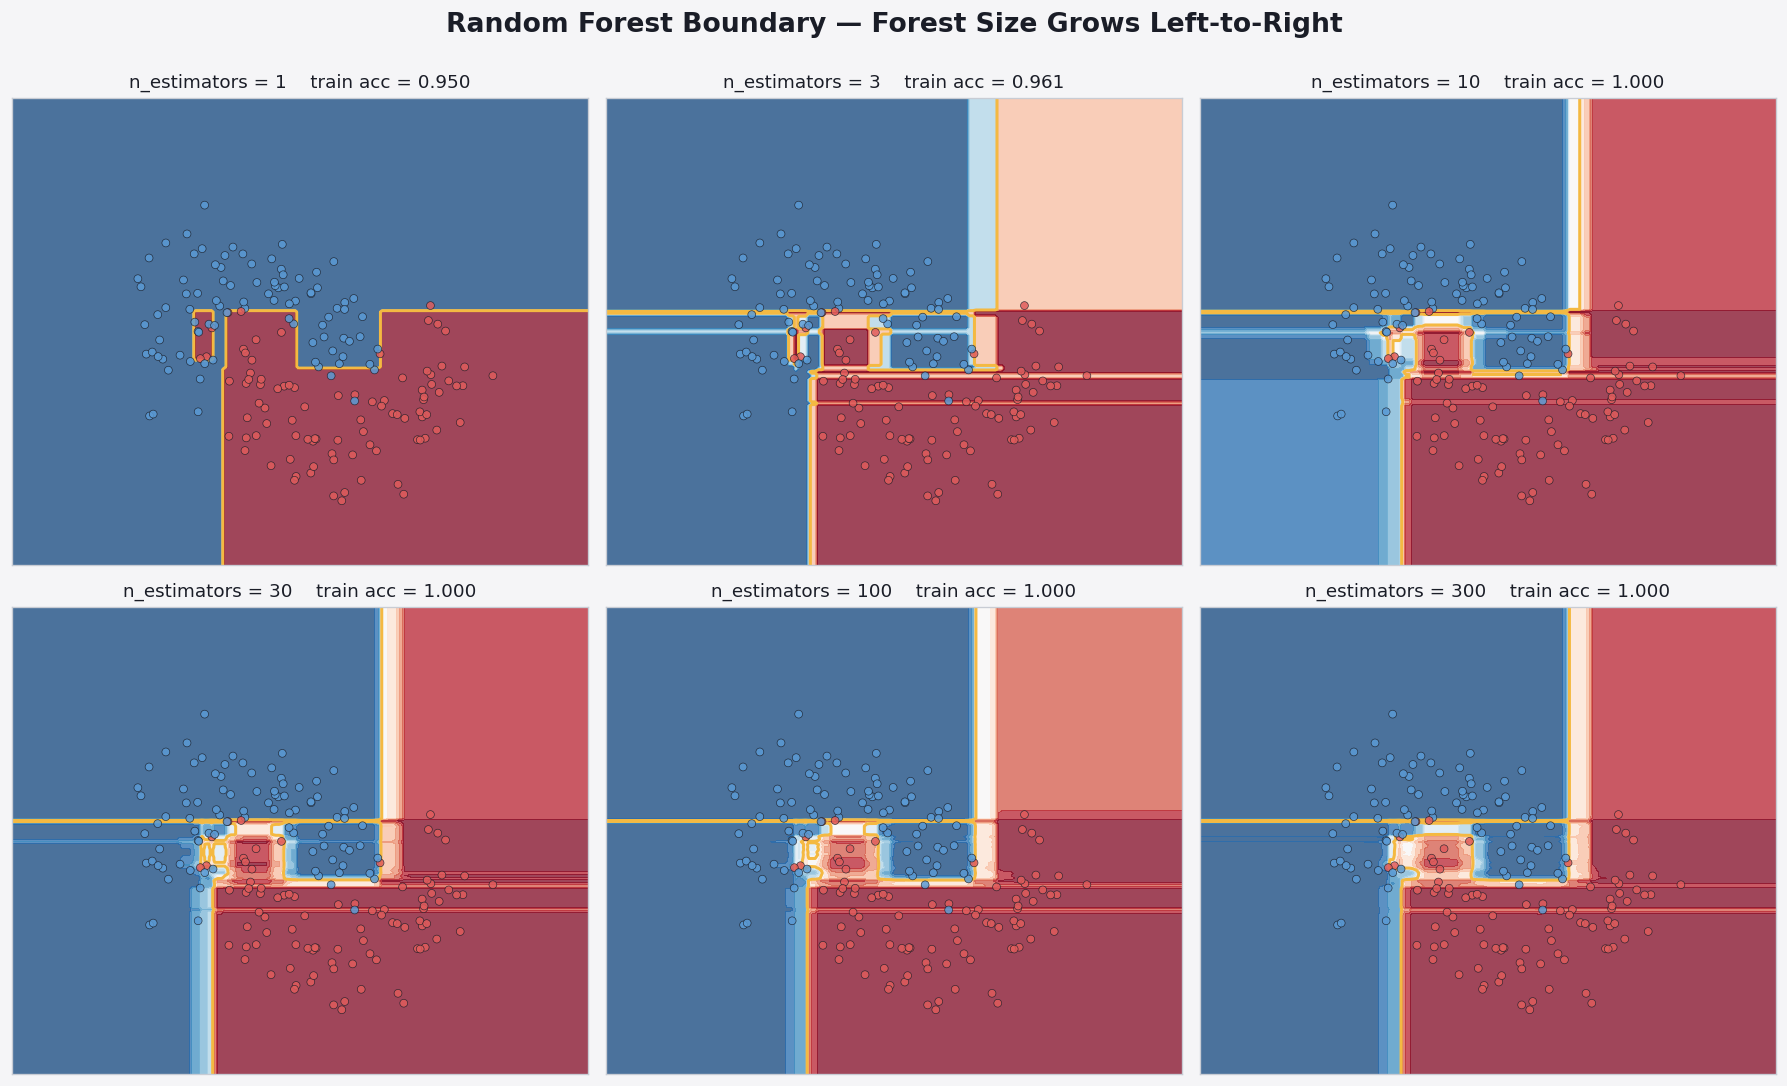

In [6]:
import warnings

_xx_rf, _yy_rf = np.meshgrid(np.linspace(-2.5, 3.5, 180),
                             np.linspace(-1.5, 2.5, 180))

# 2-D ensemble boundary at six forest sizes
_n_panel = [1, 3, 10, 30, 100, 300]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, n in zip(axes.ravel(), _n_panel):
    rf2 = RandomForestClassifier(
        n_estimators=n, max_depth=8, max_features=2,
        n_jobs=-1, random_state=0,
    ).fit(X2, y2)
    ZZ = rf2.predict_proba(np.c_[_xx_rf.ravel(), _yy_rf.ravel()])[:, 1].reshape(_xx_rf.shape)
    train_acc = accuracy_score(y2, rf2.predict(X2))
    ax.contourf(_xx_rf, _yy_rf, ZZ, levels=15, cmap='RdBu_r', alpha=0.75)
    ax.contour(_xx_rf, _yy_rf, ZZ, levels=[0.5], colors=CB, linewidths=1.8)
    ax.scatter(X2[:, 0], X2[:, 1],
               c=[C1 if yi else C0 for yi in y2],
               s=22, edgecolors='#1a1d27', lw=0.4, alpha=0.85, zorder=4)
    ax.set_title(f'n_estimators = {n}    train acc = {train_acc:.3f}',
                 fontsize=11, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Random Forest Boundary — Forest Size Grows Left-to-Right',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()


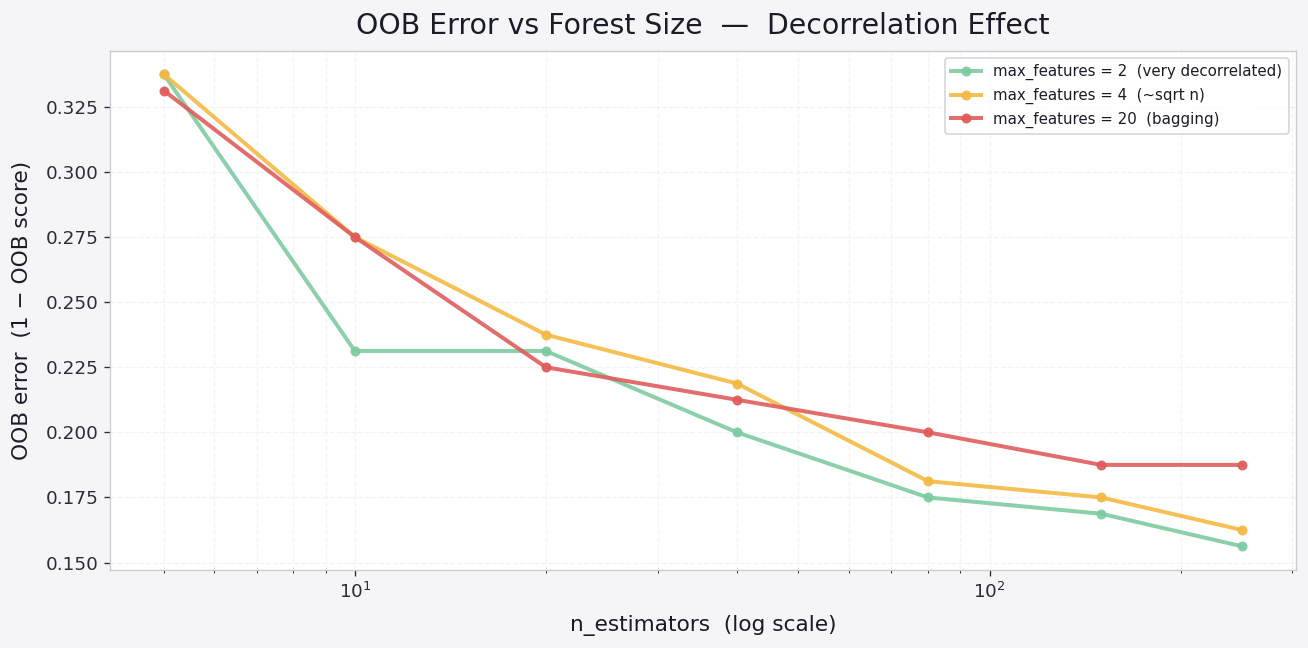

In [7]:
# OOB error vs forest size, for three settings of max_features
_n_feat_total = X_tr.shape[1]
_n_grid = [5, 10, 20, 40, 80, 150, 250]
_mf_tiers = [2, max(2, int(np.sqrt(_n_feat_total))), _n_feat_total]
_oob_by_feat = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for _mf in _mf_tiers:
        _curve = []
        for _n in _n_grid:
            _rf = RandomForestClassifier(
                n_estimators=_n, max_depth=8,
                max_features=min(_mf, _n_feat_total),
                oob_score=True, bootstrap=True,
                n_jobs=-1, random_state=0,
            ).fit(X_tr, y_tr)
            _curve.append(1.0 - _rf.oob_score_)
        _oob_by_feat[_mf] = _curve

_label_map = {
    _mf_tiers[0]: f'max_features = {_mf_tiers[0]}  (very decorrelated)',
    _mf_tiers[1]: f'max_features = {_mf_tiers[1]}  (~sqrt n)',
    _mf_tiers[2]: f'max_features = {_mf_tiers[2]}  (bagging)',
}
_color_map = {_mf_tiers[0]: CM, _mf_tiers[1]: CB, _mf_tiers[2]: C1}

fig, ax = plt.subplots(figsize=(11, 5.5))
for _mf, _curve in _oob_by_feat.items():
    ax.semilogx(_n_grid, _curve, color=_color_map[_mf], lw=2.4,
                marker='o', ms=5, alpha=0.9, label=_label_map[_mf])
ax.set_xlabel('n_estimators  (log scale)', labelpad=8)
ax.set_ylabel('OOB error  (1 − OOB score)', labelpad=8)
ax.set_title('OOB Error vs Forest Size  —  Decorrelation Effect', pad=10)
ax.legend(loc='upper right', fontsize=9); ax.grid(True, which='both', alpha=0.4)
plt.tight_layout(); plt.show()


---
## Feature Importance & Metrics

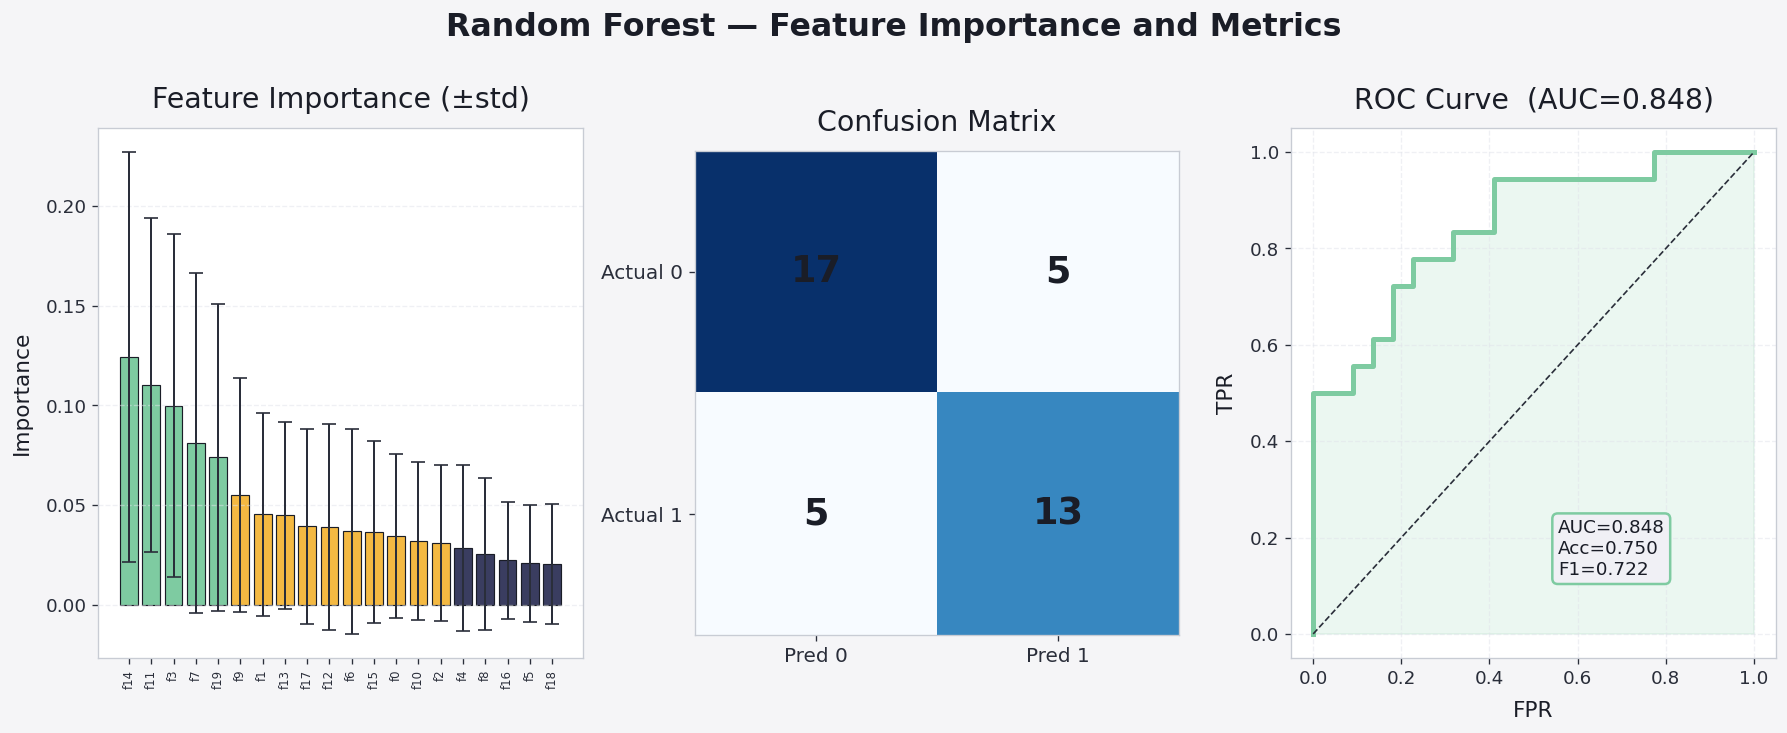

In [8]:
rf_final = RandomForestClassifier(n_estimators=200, max_depth=8,
                                   max_features='sqrt', random_state=42)
rf_final.fit(X_tr, y_tr)
preds   = rf_final.predict(X_te)
probs   = rf_final.predict_proba(X_te)[:,1]
cm      = confusion_matrix(y_te, preds)
fpr, tpr, _ = roc_curve(y_te, probs)
roc_auc = auc(fpr, tpr)

importances = rf_final.feature_importances_
std_imp     = np.std([t.feature_importances_ for t in rf_final.estimators_], axis=0)
sort_idx    = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Feature importance
ax = axes[0]
cols_i = [CM if importances[i]>0.06 else CB if importances[i]>0.03 else '#3a3d60'
          for i in sort_idx]
ax.bar(range(20), importances[sort_idx], yerr=std_imp[sort_idx],
       color=cols_i, edgecolor='#1a1d27', lw=0.7,
       error_kw=dict(ecolor='#2a2e3a', capsize=4, lw=1.2))
ax.set_xticks(range(20))
ax.set_xticklabels([f'f{i}' for i in sort_idx], rotation=90, fontsize=7)
ax.set_ylabel('Importance', labelpad=8)
ax.set_title('Feature Importance (±std)', pad=12)
ax.grid(True, axis='y')

# Confusion matrix
ax = axes[1]
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=22, fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0','Pred 1'], fontsize=12)
ax.set_yticklabels(['Actual 0','Actual 1'], fontsize=12)
ax.set_title('Confusion Matrix', pad=12)

# ROC
ax = axes[2]
ax.plot(fpr, tpr, color=CM, lw=3)
ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1)
ax.set_xlabel('FPR', labelpad=8); ax.set_ylabel('TPR', labelpad=8)
ax.set_title(f'ROC Curve  (AUC={roc_auc:.3f})', pad=12)
ax.grid(True)
for metric, val, col in [
    ('Acc', accuracy_score(y_te,preds), CM),
    ('F1',  f1_score(y_te,preds),       CB),
]:
    pass  # already shown in title
ax.text(0.55, 0.15, f'AUC={roc_auc:.3f}\nAcc={accuracy_score(y_te,preds):.3f}\nF1={f1_score(y_te,preds):.3f}',
        transform=ax.transAxes, fontsize=11, va='bottom',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=CM, lw=1.5))

fig.suptitle('Random Forest — Feature Importance and Metrics',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

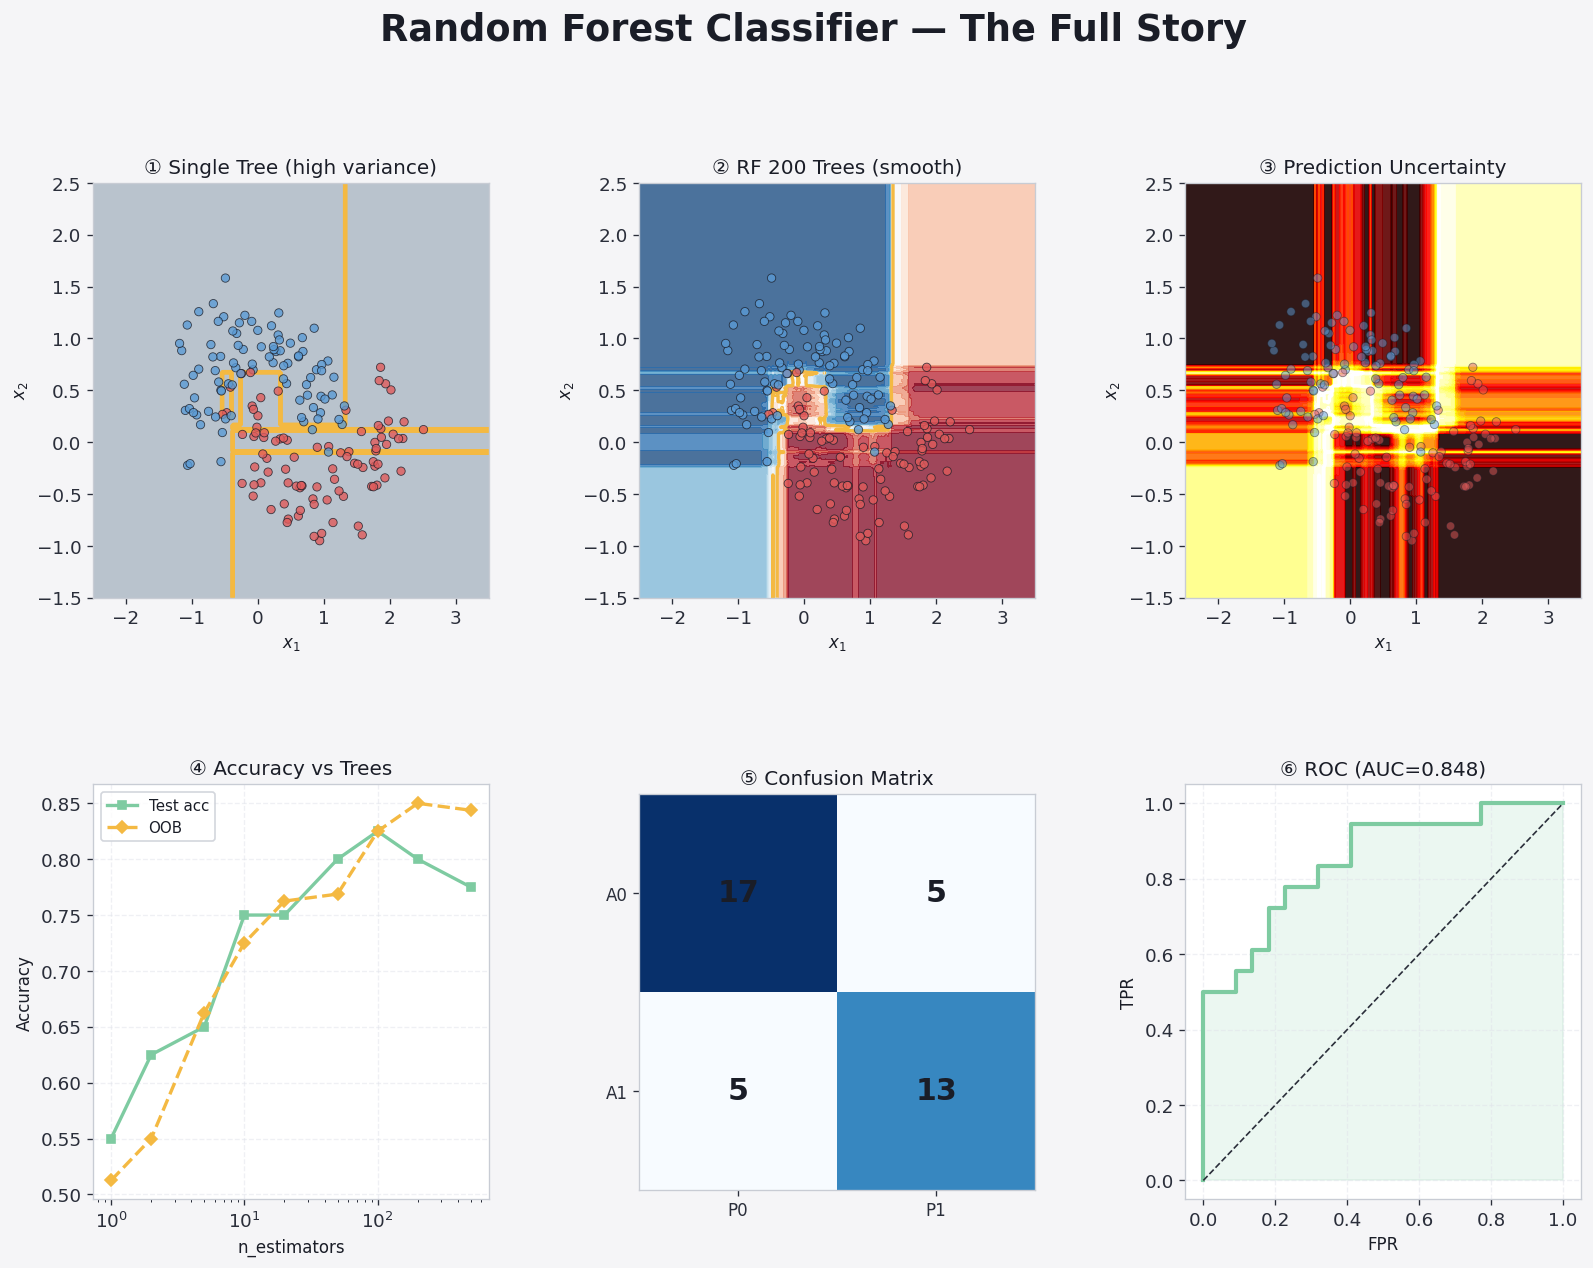

In [9]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax = fig.add_subplot(gs[0,0])
ZZ_s2 = clf_single.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
ax.contourf(xx,yy,ZZ_s2,alpha=0.3,colors=['#1a3a5c','#5c1a1a'])
ax.contour(xx,yy,ZZ_s2,colors=CB,linewidths=2)
ax.scatter(X2[:,0],X2[:,1],c=[C1 if yi else C0 for yi in y2],s=25,edgecolors='#1a1d27',lw=0.5,alpha=0.8,zorder=4)
ax.set_title('① Single Tree (high variance)',fontsize=12)
ax.set_xlabel('$x_1$',fontsize=10);ax.set_ylabel('$x_2$',fontsize=10)

ax = fig.add_subplot(gs[0,1])
ax.contourf(xx,yy,ZZ_200,levels=15,cmap='RdBu_r',alpha=0.75)
ax.contour(xx,yy,ZZ_200,levels=[0.5],colors=CB,linewidths=2)
ax.scatter(X2[:,0],X2[:,1],c=[C1 if yi else C0 for yi in y2],s=25,edgecolors='#1a1d27',lw=0.5,alpha=0.8,zorder=4)
ax.set_title('② RF 200 Trees (smooth)',fontsize=12)
ax.set_xlabel('$x_1$',fontsize=10);ax.set_ylabel('$x_2$',fontsize=10)

ax = fig.add_subplot(gs[0,2])
ax.contourf(xx,yy,std_map,levels=20,cmap='hot',alpha=0.9)
ax.contour(xx,yy,ZZ_200,levels=[0.5],colors='#ffffff',linewidths=2)
ax.scatter(X2[:,0],X2[:,1],c=[C1 if yi else C0 for yi in y2],s=25,edgecolors='#1a1d27',lw=0.5,alpha=0.5,zorder=5)
ax.set_title('③ Prediction Uncertainty',fontsize=12)
ax.set_xlabel('$x_1$',fontsize=10);ax.set_ylabel('$x_2$',fontsize=10)

ax = fig.add_subplot(gs[1,0])
ax.semilogx(n_est_list,test_acc_list,color=CM,lw=2,marker='s',ms=5,label='Test acc')
ax.semilogx(n_est_list,oob_list,color=CB,lw=2,marker='D',ms=5,ls='--',label='OOB')
ax.set_title('④ Accuracy vs Trees',fontsize=12)
ax.set_xlabel('n_estimators',fontsize=10);ax.set_ylabel('Accuracy',fontsize=10)
ax.legend(fontsize=9);ax.grid(True)

ax = fig.add_subplot(gs[1,1])
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=18,fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]);ax.set_yticks([0,1])
ax.set_xticklabels(['P0','P1'],fontsize=10);ax.set_yticklabels(['A0','A1'],fontsize=10)
ax.set_title('⑤ Confusion Matrix',fontsize=12)

ax = fig.add_subplot(gs[1,2])
ax.plot(fpr,tpr,color=CM,lw=2.5)
ax.fill_between(fpr,tpr,alpha=0.15,color=CM)
ax.plot([0,1],[0,1],color='#2a2e3a',ls='--',lw=1)
ax.set_title(f'⑥ ROC (AUC={roc_auc:.3f})',fontsize=12)
ax.set_xlabel('FPR',fontsize=10);ax.set_ylabel('TPR',fontsize=10);ax.grid(True)

fig.suptitle('Random Forest Classifier — The Full Story',fontsize=22,fontweight='bold',color='#1a1d27',y=1.01)
plt.show()

---
## ⚖️ When to use Random Forest (classification) — and when not to

| Situation | RF | Gradient Boosting | Logistic | KNN |
|---|---|---|---|---|
| First non-linear baseline | ✅ ~no tuning | ❌ needs tuning | ✅ | partial |
| State-of-the-art on tabular | usually 2nd | ✅ usually 1st | ❌ | ❌ |
| Probability calibration | partial | partial | ✅ best | ❌ |
| Real-time prediction | ✅ parallel | partial | ✅ | ❌ |

> The default classifier when you have **mixed-type tabular features and no time to tune**.


---
## 🎯 Try this

1. **Class imbalance.** Train on a 95/5 split with `class_weight=None` vs `balanced`. Then try undersampling and SMOTE. Compare ROC-AUC and PR-AUC.
2. **Tree count.** Plot OOB error vs `n_estimators` from 1 to 1000 — the curve should plateau by 200–500 trees.
3. **Permutation importance.** Compute `permutation_importance` on a held-out set. It often disagrees with `feature_importances_` (which is biased toward high-cardinality features).


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Bootstrap sample | $m$ points drawn with replacement | Each tree sees ~63% unique training points |
| Random feature split | Consider only $\sqrt{p}$ features per split | Decorrelates trees → bigger variance reduction |
| Majority vote | Class predicted by most trees wins | Smoother probability estimates than single tree |
| OOB score | Accuracy on out-of-bag points | Free cross-validation — no held-out set needed |
| n_estimators | Number of trees | More → more stable; diminishing returns after ~100 |
| max_features | Features considered per split | Smaller → more diverse trees |
| Feature importance | Mean impurity decrease ± std across trees | More reliable than single-tree importance |

**Key insight:** Random Forest reduces variance by averaging many diverse trees trained on different bootstrap samples with random feature subsets. The ensemble boundary is smooth and stable where a single tree's boundary would be jagged and noisy.